#### Searching for the Higgs Boson #

The Standard Model is a theory in particle physics that describes some of the most basic forces of nature. One fundamental particle, the Higgs boson, is what accounts for the *mass* of matter. First theorized in the 1964, the Higgs boson eluded observation for almost fifty years. In 2012 it was finally observed experimentally at the Large Hadron Collider. These experiments produced millions of gigabytes of data.

Large and complicated datasets like these are where deep learning excels. In this notebook, we'll build a Wide and Deep neural network to determine whether an observed particle collision produced a Higgs boson or not.

# The Collision Data #

The collision of protons at high energy can produce new particles like the Higgs boson. These particles can't be directly observed, however, since they decay almost instantly. So to detect the presence of a new particle, we instead observe the behavior of the particles they decay into, their "decay products".

The *Higgs* dataset contains 21 "low-level" features of the decay products and also 7 more "high-level" features derived from these.

# Wide and Deep Neural Networks #

A *Wide and Deep* network trains a linear layer side-by-side with a deep stack of dense layers. Wide and Deep networks are often effective on tabular datasets.[^1]

Both the dataset and the model are much larger than what we used in the course. To speed up training, we'll use Kaggle's [Tensor Processing Units](https://www.kaggle.com/docs/tpu) (TPUs), an accelerator ideal for large workloads.

We've collected some hyperparameters here to make experimentation easier. Fork this notebook by [**clicking here**](https://www.kaggle.com/kernels/fork/12171965) to try it yourself!

In [1]:
# Model Configuration
UNITS = 2 ** 11 # 2048
ACTIVATION = 'relu'
DROPOUT = 0.1

# Training Configuration
BATCH_SIZE_PER_REPLICA = 2 ** 11 # powers of 128 are best

The next few sections set up the TPU computation, data pipeline, and neural network model. If you'd just like to see the results, feel free to skip to the end!

# Setup #

In addition to our imports, this section contains some code that will connect our notebook to the TPU and create a **distribution strategy**. Each TPU has eight computational cores acting independently. With a distribution strategy, we define how we want to divide up the work between them.

In [2]:
# TensorFlow
import tensorflow as tf
print("Tensorflow version " + tf.__version__)

# Detect and init the TPU
try: # detect TPUs
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver() # TPU detection
    strategy = tf.distribute.TPUStrategy(tpu)
except ValueError: # detect GPUs
    strategy = tf.distribute.get_strategy() # default strategy that works on CPU and single GPU
print("Number of accelerators: ", strategy.num_replicas_in_sync)
    
# Plotting
import pandas as pd
import matplotlib.pyplot as plt

# Matplotlib defaults
plt.style.use('seaborn-v0_8-whitegrid')
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)


# Data
from kaggle_datasets import KaggleDatasets
from tensorflow.io import FixedLenFeature
AUTO = tf.data.experimental.AUTOTUNE


# Model
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import callbacks

2024-07-31 09:24:50.099613: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-31 09:24:50.099744: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-31 09:24:50.225040: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Tensorflow version 2.15.0
Number of accelerators:  1


Notice that TensorFlow now detects eight accelerators. Using a TPU is a bit like using eight GPUs at once.

# Load Data #

The dataset has been encoded in a binary file format called *TFRecords*. These two functions will parse the TFRecords and build a TensorFlow `tf.data.Dataset` object that we can use for training.

In [3]:
def make_decoder(feature_description):
    def decoder(example):
        example = tf.io.parse_single_example(example, feature_description)
        features = tf.io.parse_tensor(example['features'], tf.float32)
        features = tf.reshape(features, [28])
        label = example['label']
        return features, label
    return decoder

def load_dataset(filenames, decoder, ordered=False):
    AUTO = tf.data.experimental.AUTOTUNE
    ignore_order = tf.data.Options()
    if not ordered:
        ignore_order.experimental_deterministic = False
    dataset = (
        tf.data
        .TFRecordDataset(filenames, num_parallel_reads=AUTO)
        .with_options(ignore_order)
        .map(decoder, AUTO)
    )
    return dataset

In [4]:
dataset_size = int(11e6)
validation_size = int(5e5)
training_size = dataset_size - validation_size

# For model.fit
batch_size = BATCH_SIZE_PER_REPLICA * strategy.num_replicas_in_sync
steps_per_epoch = training_size // batch_size
validation_steps = validation_size // batch_size

# For model.compile
steps_per_execution = 256

In [5]:
feature_description = {
    'features': FixedLenFeature([], tf.string),
    'label': FixedLenFeature([], tf.float32),
}
decoder = make_decoder(feature_description)

data_dir = '/kaggle/input/higgs-boson'
train_files = tf.io.gfile.glob(data_dir + '/training' + '/*.tfrecord')
valid_files = tf.io.gfile.glob(data_dir + '/validation' + '/*.tfrecord')

ds_train = load_dataset(train_files, decoder, ordered=False)
ds_train = (
    ds_train
    .cache()
    .repeat()
    .shuffle(2 ** 19)
    .batch(batch_size)
    .prefetch(AUTO)
)

ds_valid = load_dataset(valid_files, decoder, ordered=False)
ds_valid = (
    ds_valid
    .batch(batch_size)
    .cache()
    .prefetch(AUTO)
)

# Model #

Now that the data is ready, let's define the network. We're defining the deep branch of the network using Keras's *Functional API*, which is a bit more flexible that the `Sequential` method we used in the course.


In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Define constants
UNITS = 128  # Number of units in dense layers
ACTIVATION = 'relu'  # Activation function
DROPOUT = 0.5  # Dropout rate
steps_per_execution = 100  # Example value

def dense_block(units, activation, dropout_rate):
    def block(x):
        x = layers.Dense(units, activation=activation)(x)
        x = layers.Dropout(dropout_rate)(x)
        return x
    return block

# Wide Network
# Define the wide model
wide_input = keras.Input(shape=(1,))
wide_output = layers.Dense(1, activation='linear')(wide_input)
wide_model = keras.Model(inputs=wide_input, outputs=wide_output)

# Define the deep model
deep_inputs = keras.Input(shape=[28])
x = dense_block(UNITS, ACTIVATION, DROPOUT)(deep_inputs)
x = dense_block(UNITS, ACTIVATION, DROPOUT)(x)
x = dense_block(UNITS, ACTIVATION, DROPOUT)(x)
x = dense_block(UNITS, ACTIVATION, DROPOUT)(x)
x = dense_block(UNITS, ACTIVATION, DROPOUT)(x)
deep_outputs = layers.Dense(1)(x)
deep_model = keras.Model(inputs=deep_inputs, outputs=deep_outputs)

# Wide and Deep Model
wide_and_deep_inputs = keras.Input(shape=(28,))
wide_features = wide_and_deep_inputs[:, 0:1]  # Extracting the feature for the wide model
wide_output = wide_model(wide_features)
deep_output = deep_model(wide_and_deep_inputs)

# Combine outputs
combined_output = layers.Add()([wide_output, deep_output])
final_output = layers.Activation('sigmoid')(combined_output)

# Final Model
wide_and_deep_model = keras.Model(inputs=wide_and_deep_inputs, outputs=final_output)

# Compile the model
wide_and_deep_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['AUC', 'binary_accuracy'],
)

# Model summary
wide_and_deep_model.summary()


Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 28)]                 0         []                            
                                                                                                  
 tf.__operators__.getitem (  (None, 1)                    0         ['input_3[0][0]']             
 SlicingOpLambda)                                                                                 
                                                                                                  
 model (Functional)          (None, 1)                    2         ['tf.__operators__.getitem[0][
                                                                    0]']                          
                                                                                            

# Training #

During training, we'll use the `EarlyStopping` callback as usual. Notice that we've also defined a **learning rate schedule**. It's been found that gradually decreasing the learning rate over the course of training can improve performance (the weights "settle in" to a minimum). This schedule will multiply the learning rate by `0.2` if the validation loss didn't decrease after an epoch.

In [7]:
early_stopping = callbacks.EarlyStopping(
    patience=2,
    min_delta=0.001,
    restore_best_weights=True,
)

lr_schedule = callbacks.ReduceLROnPlateau(
    patience=0,
    factor=0.2,
    min_lr=0.001,
)

In [8]:
history = wide_and_deep_model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=50,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[early_stopping],
)

Epoch 1/50


I0000 00:00:1722417922.319097      77 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5126/5126 [==============================] - 368s 68ms/step - loss: 0.6046 - auc: 0.7321 - binary_accuracy: 0.6687 - val_loss: 0.5810 - val_auc: 0.7838 - val_binary_accuracy: 0.6865
Epoch 2/50
5126/5126 [==============================] - 38s 7ms/step - loss: 0.5733 - auc: 0.7691 - binary_accuracy: 0.7005 - val_loss: 0.5660 - val_auc: 0.7969 - val_binary_accuracy: 0.7012
Epoch 3/50
5126/5126 [==============================] - 38s 7ms/step - loss: 0.5661 - auc: 0.7765 - binary_accuracy: 0.7060 - val_loss: 0.5573 - val_auc: 0.8021 - val_binary_accuracy: 0.7058
Epoch 4/50
5126/5126 [==============================] - 38s 7ms/step - loss: 0.5621 - auc: 0.7806 - binary_accuracy: 0.7091 - val_loss: 0.5552 - val_auc: 0.8057 - val_binary_accuracy: 0.7087
Epoch 5/50
5126/5126 [==============================] - 38s 7ms/step - loss: 0.5591 - auc: 0.7834 - binary_accuracy: 0.7111 - val_loss: 0.5617 - val_auc: 0.8084 - val_binary_accuracy: 0.6994
Epoch 6/50
5126/5126 [==============================] 

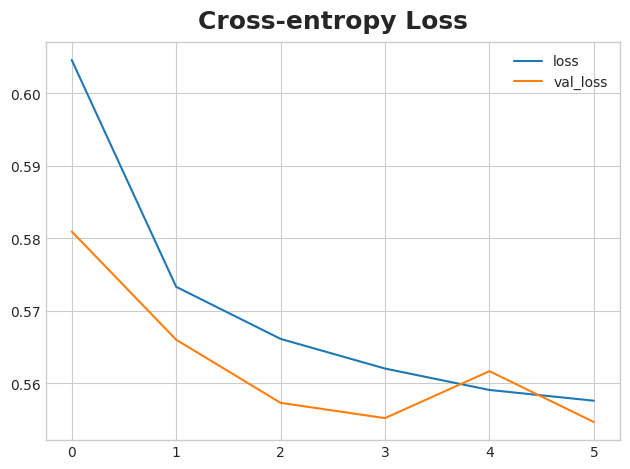

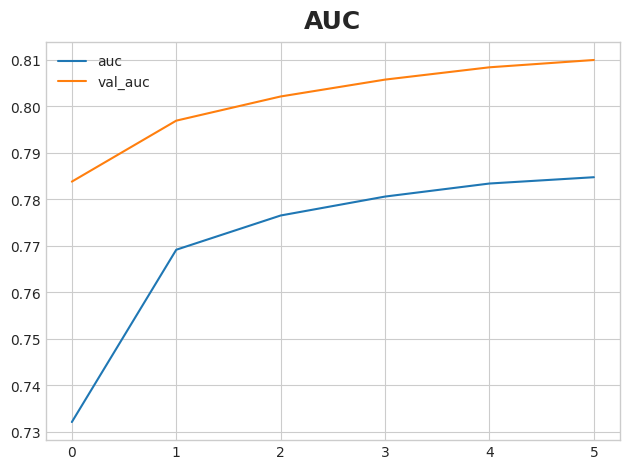

In [9]:
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot(title='Cross-entropy Loss')
history_frame.loc[:, ['auc', 'val_auc']].plot(title='AUC');

# References #

- Baldi, P. et al. *Searching for Exotic Particles in High-Energy Physics with Deep Learning*. (2014) ([arXiv](https://arxiv.org/abs/1402.4735))
- Cheng, H. et al. *Wide & Deep Learning for Recommender Systems*. (2016) ([arXiv](https://arxiv.org/abs/1606.07792))
- *What Exactly is the Higgs Boson?* Scientific American. (1999) [(article)](https://www.scientificamerican.com/article/what-exactly-is-the-higgs/)]

[^1]: In the original implementation, categorical features were one-hot encoded and crossed to produce the interaction features. This "wide" dataset was used with the linear component. For the deep component, the categories were encoded into a much narrower embedding layer.

---




*Have questions or comments? Visit the [Learn Discussion forum](https://www.kaggle.com/learn-forum/191966) to chat with other Learners.*